In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [8]:
# Load the dataset
wine = load_wine()
X = wine.data
y = wine.target

In [7]:
print(f"Dataset loaded. X shape: {X.shape}, y shape: {y.shape}")

Dataset loaded. X shape: (178, 13), y shape: (178,)


In [9]:
# Splitting the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data split into 80% Training and 20% Testing.")

Data split into 80% Training and 20% Testing.


In [10]:
# Initialize and apply StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Data standardized (Mean=0, StdDev=1).")

Data standardized (Mean=0, StdDev=1).


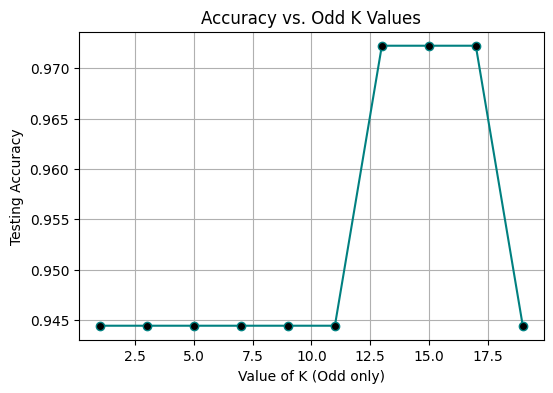

The optimal odd K value is: 13 with 97.22% accuracy.


In [13]:
accuracies = []
# range(start, stop, step) -> step of 2 ensures we only get odd numbers: 1, 3, 5...
k_neighbors = range(1, 21, 2)

for k in k_neighbors:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    score = knn.score(X_test, y_test)
    accuracies.append(score)

# Identify the best odd k
best_k = list(k_neighbors)[np.argmax(accuracies)]

# Visualizing the results
plt.figure(figsize=(6, 4))
plt.plot(list(k_neighbors), accuracies, color='teal', linestyle='-', marker='o', markerfacecolor='black')
plt.title('Accuracy vs. Odd K Values')
plt.xlabel('Value of K (Odd only)')
plt.ylabel('Testing Accuracy')
plt.grid(True)
plt.show()

print(f"The optimal odd K value is: {best_k} with {max(accuracies)*100:.2f}% accuracy.")

In [14]:
# 1. Train the final model
final_model = KNeighborsClassifier(n_neighbors=best_k)
final_model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=13)

In [17]:
# 2. Define a new data point (using the average of all wines as a sample)
new_sample = np.array([X.mean(axis=0)])

In [18]:
# 3. IMPORTANT: Scale the new data point using the same scaler
new_sample_scaled = scaler.transform(new_sample)

In [19]:
# 4. Perform Prediction
prediction = final_model.predict(new_sample_scaled)
result_name = wine.target_names[prediction][0]

In [20]:
print(f"Input Data (Scaled): {new_sample_scaled}")
print(f"Prediction: The model classifies this wine as Class {prediction[0]} ({result_name})")

Input Data (Scaled): [[ 0.02634957 -0.03261062  0.02038504  0.00630464 -0.0480912   0.00948572
   0.02713995 -0.04830562 -0.02945216  0.00020849  0.00458324  0.02622105
   0.0398294 ]]
Prediction: The model classifies this wine as Class 0 (class_0)
